In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports & Setup


In [ ]:
# ================================================================
#   IMPORTS AND SETUP
# ================================================================
import os
import random
import shutil
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


Balance Data (Merge & Re-split)

In [ ]:
# ================================================================
# BALANCE DATA
# ================================================================
print("\n" + "="*60)
print("Balancing and Re-splitting Data")
print("="*60)

src_root = '/content/drive/MyDrive/DataFiles/War_Data'
dst_root = '/content/War_Data_balanced'

splits_in = ['train', 'val', 'test']
split_ratios = {'train': 0.70, 'val': 0.15, 'test': 0.15}
random.seed(42)

# Collect all images per class (with extension filtering)
all_files = {}
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

for split in splits_in:
    split_path = os.path.join(src_root, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        all_files.setdefault(cls, [])
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(valid_extensions):
                all_files[cls].append(os.path.join(cls_path, fname))

print("Total images collected per class:")
for cls, files in all_files.items():
    print(f"   {cls}: {len(files)}")

# Re-split each class with fixed ratios
if os.path.exists(dst_root):
    shutil.rmtree(dst_root)

for cls, files in all_files.items():
    random.shuffle(files)
    n = len(files)
    n_train = int(n * split_ratios['train'])
    n_val = int(n * split_ratios['val'])
    n_test = n - n_train - n_val

    splits_files = {
        'train': files[:n_train],
        'val': files[n_train:n_train + n_val],
        'test': files[n_train + n_val:]
    }

    for split, file_list in splits_files.items():
        dst_dir = os.path.join(dst_root, split, cls)
        os.makedirs(dst_dir, exist_ok=True)
        for src_file in file_list:
            fname = os.path.basename(src_file)
            dst_file = os.path.join(dst_dir, fname)
            if not os.path.exists(dst_file):
                os.symlink(src_file, dst_file)

print("\n Data re-split completed:")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(dst_root, split)
    print(f"\n{split}/")
    for cls in sorted(os.listdir(split_path)):
        n = len(os.listdir(os.path.join(split_path, cls)))
        print(f"  {cls}: {n} files")

# Fixed class mapping
fixed_classes = sorted(all_files.keys())
class_to_idx = {cls: i for i, cls in enumerate(fixed_classes)}
print(f"\n Fixed class mapping: {class_to_idx}")


Balancing and Re-splitting Data
Total images collected per class:
   tank: 1291
   warplane: 1125
   helicopter: 888
   half_track: 669
   jeep_car: 907

 Data re-split completed:

train/
  half_track: 468 files
  helicopter: 621 files
  jeep_car: 634 files
  tank: 903 files
  warplane: 787 files

val/
  half_track: 100 files
  helicopter: 133 files
  jeep_car: 136 files
  tank: 193 files
  warplane: 168 files

test/
  half_track: 101 files
  helicopter: 134 files
  jeep_car: 137 files
  tank: 195 files
  warplane: 170 files

 Fixed class mapping: {'half_track': 0, 'helicopter': 1, 'jeep_car': 2, 'tank': 3, 'warplane': 4}


Visualize Random Samples


 Visualizing Random Samples


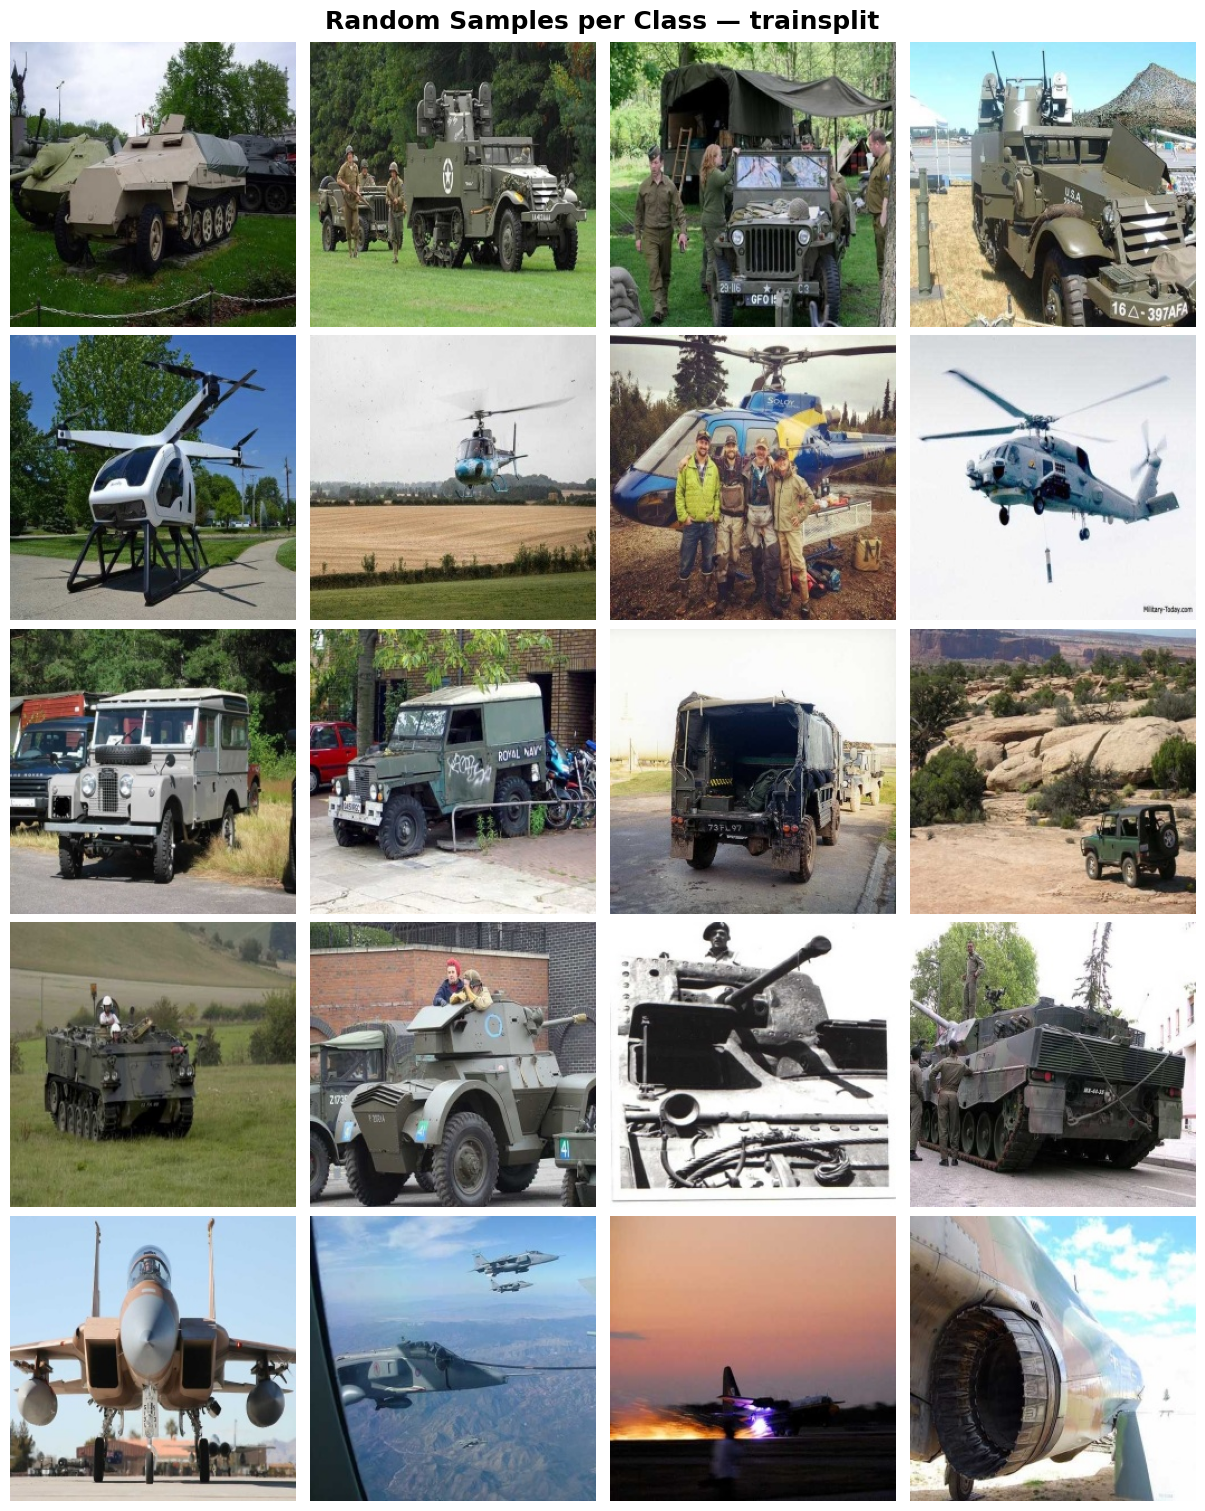

In [ ]:
# ================================================================
#  VISUALIZE RANDOM SAMPLES
# ================================================================
print("\n" + "="*60)
print(" Visualizing Random Samples")
print("="*60)

split = 'train'
n_per_class = 4
split_path = os.path.join(dst_root, split)
classes = sorted(os.listdir(split_path))
n_classes = len(classes)

fig, axes = plt.subplots(n_classes, n_per_class,
                          figsize=(n_per_class * 3, n_classes * 3),
                          constrained_layout=True)
fig.suptitle(f'Random Samples per Class — {split}split', fontsize=18, fontweight='bold')

if n_classes == 1:
    axes = axes.reshape(1, -1)

for row, cls in enumerate(classes):
    cls_path = os.path.join(split_path, cls)
    all_imgs = os.listdir(cls_path)
    sample_imgs = random.sample(all_imgs, min(n_per_class, len(all_imgs)))

    for col in range(n_per_class):
        ax = axes[row, col]
        ax.axis('off')

        if col < len(sample_imgs):
            img_path = os.path.join(cls_path, sample_imgs[col])
            try:
                img = Image.open(img_path).convert('RGB')
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, ha='center', va='center', fontsize=20, color='red')
                print(f"Failed to load: {img_path} - {e}")
        else:
            ax.set_facecolor('#f0f0f0')

        if col == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.show()

 Custom Dataset with CV2 + Augmentation

In [ ]:
# ================================================================
#   CUSTOM DATASET WITH CV2 +  OPTIMIZED AUGMENTATION
# ================================================================
print("\n" + "="*60)
print(" Creating Custom Dataset with CV2")
print("="*60)

class War_Data_CV2(Dataset):
    def __init__(self, root_dir, classes, class_to_idx, train=True, img_size=224):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = class_to_idx
        self.train = train
        self.img_size = img_size

        # Collect file paths efficiently (full read happens dynamically in __getitem__)
        self.samples = []
        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                fpath = os.path.join(cls_path, fname)
                if os.path.isfile(fpath):
                    self.samples.append((fpath, class_to_idx[cls]))

        # Normalization constants (ImageNet defaults)
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.samples)

    def augment(self, img):
        # 1. Resize early to a slightly larger size to speed up subsequent matrix operations
        img = cv2.resize(img, (self.img_size + 32, self.img_size + 32))
        h, w = img.shape[:2]

        # Random horizontal flip
        if random.random() < 0.5:
            img = cv2.flip(img, 1)

        # [MODIFIED] Tamed rotation (-10 to +10) to preserve horizontal rotor blades for helicopters
        if random.random() < 0.7:
            angle = random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        # [MODIFIED] Safer Crop scale (0.9 to 1.0) to keep vehicle structures (like tank turrets/truck beds) intact
        h, w = img.shape[:2]
        crop_scale = random.uniform(0.9, 1.0)
        new_h, new_w = int(h * crop_scale), int(w * crop_scale)

        top = random.randint(0, h - new_h)
        left = random.randint(0, w - new_w)
        img = img[top:top+new_h, left:left+new_w]

        # Bring it back to exactly the targeted size (224x224)
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Random brightness/contrast (helps distinguishing silhouettes against backgrounds)
        if random.random() < 0.7:
            alpha = random.uniform(0.8, 1.2)
            beta = random.uniform(-20, 20)
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        # Random erasing / Cutout (0.3 probability to handle occlusion)
        if random.random() < 0.3:
            h_im, w_im = img.shape[:2]
            eh = int(h_im * random.uniform(0.05, 0.15))
            ew = int(w_im * random.uniform(0.05, 0.15))
            ey = random.randint(0, h_im - eh)
            ex = random.randint(0, w_im - ew)
            img[ey:ey+eh, ex:ex+ew] = np.random.randint(0, 256, (eh, ew, 3))

        return img

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Robust Fallback system: if image is corrupted, move to the next file seamlessly
        if img is None:
            print(f"Warning: Corrupted image skipped at {img_path}")
            idx = (idx + 1) % len(self.samples)
            return self.__getitem__(idx)

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.train:
            img = self.augment(img)
        else:
            # Straightforward resize for validation/testing sets
            img = cv2.resize(img, (self.img_size, self.img_size))

        # Normalization
        img = img.astype(np.float32) / 255.0
        img = (img - self.mean) / self.std

        # Convert to PyTorch Tensor format (C, H, W)
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()
        label = torch.tensor(label, dtype=torch.long)

        return img, label

# ================================================================
#   DATASETS & DATALOADERS INITIALIZATION
# ================================================================
# Build datasets
train_dataset = War_Data_CV2(os.path.join(dst_root, 'train'), fixed_classes, class_to_idx, train=True)
val_dataset = War_Data_CV2(os.path.join(dst_root, 'val'), fixed_classes, class_to_idx, train=False)
test_dataset = War_Data_CV2(os.path.join(dst_root, 'test'), fixed_classes, class_to_idx, train=False)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

# Quick sanity check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape} | Labels sample: {labels[:10]}")


 Creating Custom Dataset with CV2
Train samples: 3413 | Val samples: 730 | Test samples: 737
Batch shape: torch.Size([64, 3, 224, 224]) | Labels sample: tensor([2, 4, 3, 2, 0, 4, 4, 3, 0, 0])


Compute Class Weights

In [ ]:
# ================================================================
#   COMPUTE CLASS WEIGHTS
# ================================================================
print("\n" + "="*60)
print("  Computing Class Weights for Imbalanced Data")
print("="*60)

# Get all labels from training set
all_train_labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(all_train_labels),
    y=all_train_labels
)

print(f" Class weights: {class_weights}")
class_weights_tensor = torch.from_numpy(class_weights).float().to(device)


  Computing Class Weights for Imbalanced Data
 Class weights: [1.45854701 1.09919485 1.07665615 0.7559247  0.86734435]


 Build EfficientNet-B0 Model

In [ ]:
# ================================================================
#   BUILD EFFICIENTNET-B0 MODEL
# ================================================================
print("\n" + "="*60)
print("  Building EfficientNet-B0 Model")
print("="*60)

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier with Dropout + Linear
num_classes = len(fixed_classes)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)
print(f"Model on {device}")
print(f" New classifier: {model.classifier}")


  Building EfficientNet-B0 Model
Model on cuda
 New classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=1280, out_features=5, bias=True)
  )
)


 Loss, Optimizer, and Scheduler

In [ ]:
# ================================================================
#   LOSS, OPTIMIZER, AND SCHEDULER
# ================================================================
# Loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer (only trainable parameters)
params_to_train = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(params_to_train, lr=1e-3)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

Training & Evaluation Functions

In [ ]:
# ================================================================
#   TRAINING AND EVALUATION FUNCTIONS
# ================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

Training Loop with Early Stopping

In [ ]:
# ================================================================
#   TRAINING LOOP WITH EARLY STOPPING
# ================================================================
print("\n" + "="*60)
print(" Training Loop with Early Stopping")
print("="*60)

num_epochs = 30
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = '/content/best_model.pth'
patience = 3
patience_counter = 0

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start_time

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    print(f"  Time: {elapsed:.1f}s | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f"  New best model saved! (val_acc={val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f" Early stopping triggered at epoch {epoch+1}")
            break

print(f"\nTraining completed! Best val accuracy: {best_val_acc:.4f}")


 Training Loop with Early Stopping

Epoch 1/30
  Train Loss: 1.0317 | Acc: 0.6880
  Val   Loss: 0.5496 | Acc: 0.8767
  Time: 32.9s | LR: 0.001000
  New best model saved! (val_acc=0.8767)

Epoch 2/30
  Train Loss: 0.5804 | Acc: 0.8412
  Val   Loss: 0.3958 | Acc: 0.8822
  Time: 33.4s | LR: 0.001000
  New best model saved! (val_acc=0.8822)

Epoch 3/30
  Train Loss: 0.4935 | Acc: 0.8509
  Val   Loss: 0.3397 | Acc: 0.8890
  Time: 33.0s | LR: 0.001000
  New best model saved! (val_acc=0.8890)

Epoch 4/30
  Train Loss: 0.4365 | Acc: 0.8655
  Val   Loss: 0.3242 | Acc: 0.8808
  Time: 33.5s | LR: 0.001000

Epoch 5/30
  Train Loss: 0.3913 | Acc: 0.8781
  Val   Loss: 0.2910 | Acc: 0.8932
  Time: 32.3s | LR: 0.001000
  New best model saved! (val_acc=0.8932)

Epoch 6/30
  Train Loss: 0.3830 | Acc: 0.8769
  Val   Loss: 0.2762 | Acc: 0.8986
  Time: 32.6s | LR: 0.001000
  New best model saved! (val_acc=0.8986)

Epoch 7/30
  Train Loss: 0.3693 | Acc: 0.8728
  Val   Loss: 0.2658 | Acc: 0.8959
  Time: 33.

Evaluate on Test Set

In [ ]:
# ================================================================
#   EVALUATE ON TEST SET
# ================================================================
print("\n" + "="*60)
print(" Evaluating on Test Set")
print("="*60)

# Load best model
model.load_state_dict(torch.load(best_model_path))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


 Evaluating on Test Set
Test Loss: 0.2567
Test Accuracy: 0.9023


 Plot Learning Curves


 Plotting Learning Curves


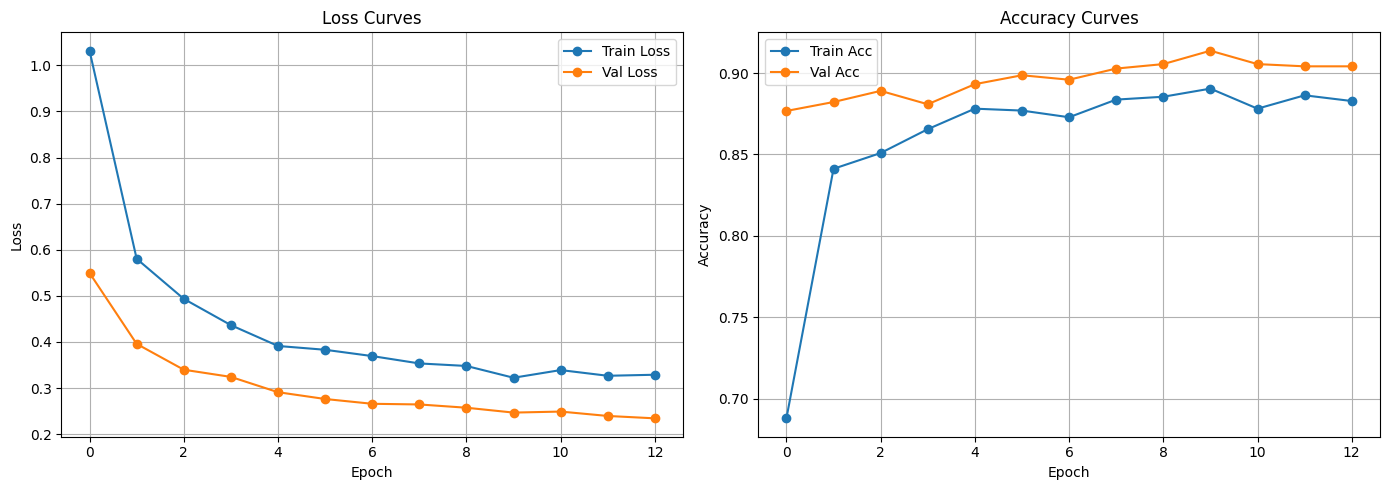

In [ ]:
# ================================================================
#   PLOT LEARNING CURVES
# ================================================================
print("\n" + "="*60)
print(" Plotting Learning Curves")
print("="*60)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'], label='Val Acc', marker='o')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Confusion Matrix


 Confusion Matrix


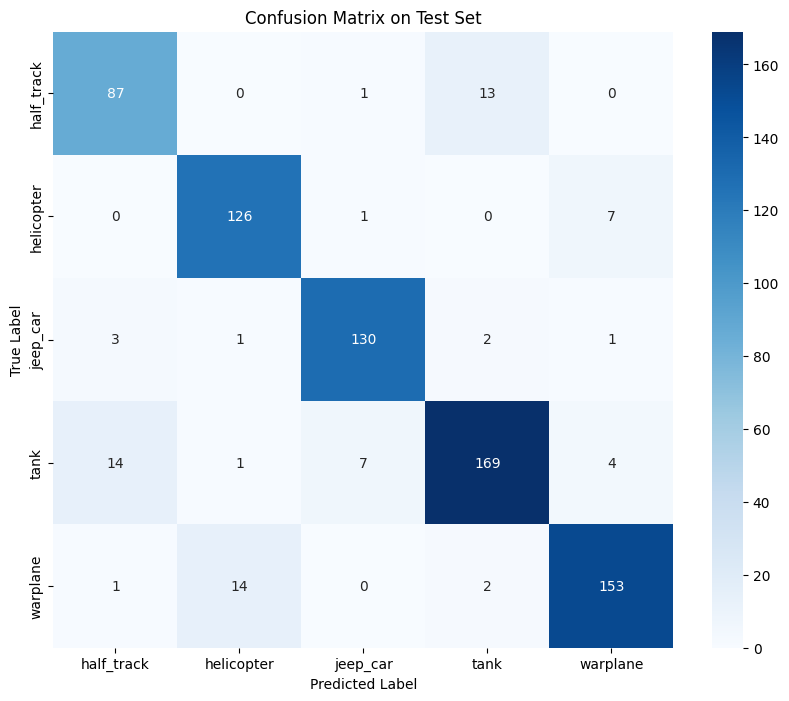

In [ ]:
# ================================================================
#  CONFUSION MATRIX
# ================================================================
print("\n" + "="*60)
print(" Confusion Matrix")
print("="*60)

from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fixed_classes, yticklabels=fixed_classes)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



 Load the Saved Model

In [ ]:
# ================================================================
#   LOAD SAVED MODEL FOR INFERENCE
# ================================================================
print("\n" + "="*60)
print(" Loading the Saved Model")
print("="*60)

# Load the best saved model
model.load_state_dict(torch.load(best_model_path))
model.eval()
print(f" Model loaded from {best_model_path}")

# Example inference on a single image from test set
sample_img_path, sample_label = test_dataset.samples[0]
img = cv2.imread(sample_img_path, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img.astype(np.float32) / 255.0
img = (img - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img)
    _, pred = torch.max(output, 1)
    predicted_class = fixed_classes[pred.item()]
    true_class = fixed_classes[sample_label]

print(f" True class: {true_class}")
print(f" Predicted class: {predicted_class}")



 Loading the Saved Model
 Model loaded from /content/best_model.pth
 True class: half_track
 Predicted class: half_track
